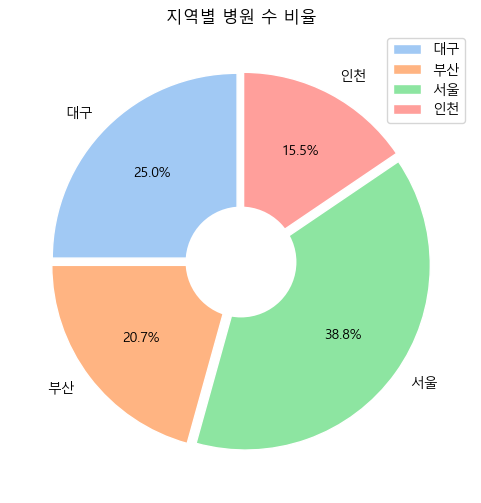

In [5]:

# 반드시 pandas는 import하여 사용
import pandas as pd
import matplotlib.pyplot as plt
# matplotlib기반에서 차트 예쁘게 꾸미는 도구
import seaborn as sns

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 병합 (지역 기준)
merged = pd.merge(df1, df2, on="지역", how="outer")

# 결측치 처리
# 총인구 없는 값 -> 평균으로 채우기
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 결과 확인
merged

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(6, 6))

# 색상
colors = sns.color_palette('pastel')

# explod 설정
explode = [0.03] * len(merged)

# 원형그래프
plt.pie(
    merged["병원수"],
    labels=merged["지역"],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    explode=explode,
    pctdistance=0.65  # %를 도넛 안쪽으로 이동
)

# 가운데 원 추가
center_circle = plt.Circle((0, 0), 0.3, fc='white')
plt.gca().add_artist(center_circle)

plt.title("지역별 병원 수 비율")
plt.legend()

plt.show()